# TransMorph3D tutorial

This notebook walks through the `transmorph3d` registration model: what it is, how it plugs into the pipeline, and how to train it with the real CLI. Like the main pipeline tutorial, the actual training run goes through the command-line entrypoint, not a reimplementation inside the notebook.

## What this notebook covers

- What TransMorph3D is and how it differs from the CNN models in this repo
- The model's input-size constraint and near-identity initialization
- Building the model from the registry and running a forward pass
- Visualizing what the model does to a synthetic sample
- Running a tiny end-to-end training via the real CLI
- Loading a saved checkpoint for inference


## The model in one paragraph

TransMorph3D follows the TransMorph design (Chen et al., 2022, *"TransMorph: Transformer for unsupervised medical image registration"*): instead of a fully convolutional encoder like `globalnet3d` / `localnet3d` / `unetreg3d`, it uses a **Swin Transformer encoder with a CNN decoder** (MONAI's `SwinUNETR`). The moving and fixed volumes are concatenated along the channel dimension, the network predicts a **dense displacement field (ddf)** with 3 channels, and MONAI's `Warp` block applies that field to the moving image. The interface is identical to the other models in `models/`:

```
warped, ddf = model(moving, fixed)
# moving, fixed: (B, 1, D, H, W)
# warped:        (B, 1, D, H, W)
# ddf:           (B, 3, D, H, W)
```

Two things to know before using it:

1. **Input size constraint.** SwinUNETR downsamples 5 times, so every spatial dimension must be **divisible by 32 and at least 64** (64, 96, 128, ...). A 32-voxel dimension would collapse to a single voxel at the bottleneck and crash the normalization layers, so the constructor rejects it up front.
2. **Near-identity initialization.** The final ddf-prediction convolution is initialized with near-zero weights, so at the start of training the model outputs an (almost) zero displacement field and `warped ≈ moving`. This is standard practice for registration networks: training starts from the identity transform instead of a random, potentially destructive warp.


In [1]:
from pathlib import Path
import sys

import torch
import yaml

repo_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(repo_root))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('repo root:', repo_root)
print('device:', device)

repo root: /home/spellsharp/0_Work/MedAI/MONAI/USRegistrator
device: cuda


## Building the model from the registry

Like every model in this repo, `transmorph3d` is registered under a string key, so `build_model` can construct it straight from the `model:` section of a YAML config. Here we build a small version by hand (the real config uses `feature_size: 48`).


In [2]:
from models import build_model, MODEL_REGISTRY

print('registered models:', list(MODEL_REGISTRY.keys()))

image_size = (64, 64, 64)
model_cfg = {
    'name': 'transmorph3d',
    'feature_size': 24,  # real config uses 48; 24 keeps the demo light
}
model = build_model(model_cfg, image_size=image_size).to(device).eval()

n_params = sum(p.numel() for p in model.parameters())
print(f'parameters: {n_params / 1e6:.2f} M')

registered models: ['globalnet3d', 'localnet3d', 'unetreg3d', 'transmorph3d']


parameters: 15.70 M


/home/spellsharp/Applications/miniconda/miniconda3/envs/base_env/lib/python3.12/site-packages/monai/networks/blocks/warp.py:72: UserWarning: monai.networks.blocks.Warp: Using PyTorch native grid_sample.
  warnings.warn("monai.networks.blocks.Warp: Using PyTorch native grid_sample.")


The size constraint is enforced at construction time, so a bad `image_size` fails immediately instead of mid-training:

In [3]:
try:
    build_model(model_cfg, image_size=(32, 32, 32))
except ValueError as e:
    print('rejected as expected:', e)

rejected as expected: TransMorph3D requires each spatial dimension to be divisible by 32 and at least 64, got image_size=[32, 32, 32].


## Forward pass and the near-identity start

We generate one sample from the built-in `deepreg_synthetic` dataset (the same one the training configs use) and push it through the untrained model. Because of the near-zero ddf-head initialization, the displacement field should be tiny and the warped image should be nearly identical to the moving image.


In [4]:
from datasets import build_dataset

dataset_cfg = {
    'name': 'deepreg_synthetic',
    'image_size': list(image_size),
    'num_samples': 2,
    'max_disp': 0.2,
    'cp_spacing': 8,
    'noise_std': 0.03,
    'smooth': True,
    'seed': 123,
}
ds = build_dataset(dataset_cfg, split='train')
sample = ds[0]

moving = sample['moving'].unsqueeze(0).to(device)  # (1, 1, D, H, W)
fixed = sample['fixed'].unsqueeze(0).to(device)

with torch.no_grad():
    warped, ddf = model(moving, fixed)

print('moving:', tuple(moving.shape))
print('warped:', tuple(warped.shape))
print('ddf:   ', tuple(ddf.shape))
print()
print(f'max |ddf| at init:            {ddf.abs().max().item():.2e}  (should be ~0)')
print(f'max |warped - moving| at init: {(warped - moving).abs().max().item():.2e}  (should be ~0)')

moving: (1, 1, 64, 64, 64)
warped: (1, 1, 64, 64, 64)
ddf:    (1, 3, 64, 64, 64)

max |ddf| at init:            4.28e-04  (should be ~0)
max |warped - moving| at init: 1.44e-04  (should be ~0)


## What the warp does

To make the warp visible, we bypass the untrained network and feed the dataset's **ground-truth displacement field** directly into the model's `Warp` block. Warping the moving image with the true field should bring it close to the fixed image — exactly what the network learns to predict during training.


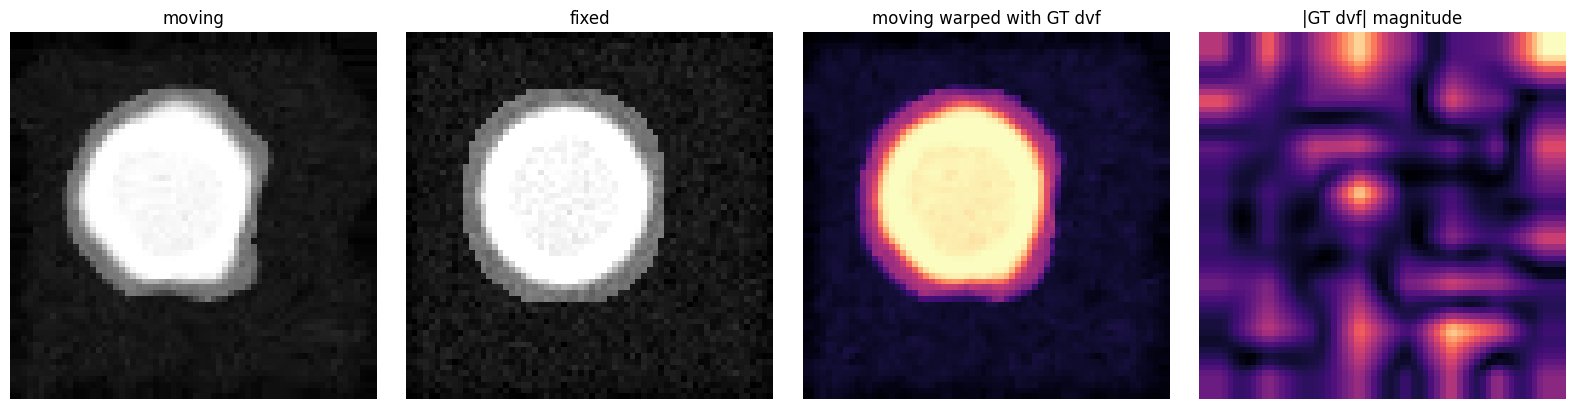

In [5]:
import matplotlib.pyplot as plt

gt_dvf = sample['dvf'].unsqueeze(0).to(device)  # (1, 3, D, H, W)
with torch.no_grad():
    warped_gt = model.warp(moving, gt_dvf)

mid = image_size[0] // 2
panels = [
    ('moving', moving[0, 0, mid].cpu()),
    ('fixed', fixed[0, 0, mid].cpu()),
    ('moving warped with GT dvf', warped_gt[0, 0, mid].cpu()),
    ('|GT dvf| magnitude', gt_dvf[0, :, mid].norm(dim=0).cpu()),
]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (title, img) in zip(axes, panels):
    im = ax.imshow(img.numpy(), cmap='gray' if 'dvf' not in title else 'magma')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

## The TransMorph3D configs

Two configs ship with the repo:

- `configs/deepreg_synth_transmorph3d.yaml` — the real training config (200 epochs, 4000 samples, `feature_size: 48`)
- `configs/deepreg_synth_transmorph3d_tutorial.yaml` — a tiny version of the same pipeline for this notebook (2 epochs, 8 samples, `feature_size: 24`, offline W&B)

The `model:` section maps one-to-one onto the `create_transmorph3d` factory arguments. Note that unlike the generic tutorial config, `image_size` here is `[64, 64, 64]` — the model's minimum valid size.


In [6]:
real_cfg_path = repo_root / 'configs' / 'deepreg_synth_transmorph3d.yaml'
tutorial_cfg_path = repo_root / 'configs' / 'deepreg_synth_transmorph3d_tutorial.yaml'

with real_cfg_path.open() as f:
    real_cfg = yaml.safe_load(f)
with tutorial_cfg_path.open() as f:
    tutorial_cfg = yaml.safe_load(f)

print('## model section of the real config')
print(yaml.safe_dump(real_cfg['model'], sort_keys=False))
print('## tutorial overrides')
for key in ['image_size']:
    print(f'{key}: real={real_cfg[key]} tutorial={tutorial_cfg[key]}')
for key in ['num_samples']:
    print(f'train_dataset.{key}: real={real_cfg["train_dataset"][key]} tutorial={tutorial_cfg["train_dataset"][key]}')
for key in ['epochs', 'batch_size']:
    print(f'training.{key}: real={real_cfg["training"][key]} tutorial={tutorial_cfg["training"][key]}')
print(f'model.feature_size: real={real_cfg["model"]["feature_size"]} tutorial={tutorial_cfg["model"]["feature_size"]}')

## model section of the real config
name: transmorph3d
feature_size: 48
depths:
- 2
- 2
- 2
- 2
num_heads:
- 3
- 6
- 12
- 24
window_size: 7
drop_rate: 0.0
attn_drop_rate: 0.0
dropout_path_rate: 0.0
use_checkpoint: false
warp_mode: bilinear
warp_padding_mode: border

## tutorial overrides
image_size: real=[64, 64, 64] tutorial=[64, 64, 64]
train_dataset.num_samples: real=4000 tutorial=8
training.epochs: real=200 tutorial=2
training.batch_size: real=2 tutorial=1
model.feature_size: real=48 tutorial=24


## Tutorial run: train through the real CLI

As in the main pipeline tutorial, training goes through the actual entrypoint. For everyday use you would edit the real config and run `python main.py --config configs/deepreg_synth_transmorph3d.yaml`; here we point at the tiny tutorial config so the run finishes in a couple of minutes (faster with a GPU).

The run logs to Weights & Biases in **offline** mode (see the `wandb:` section of the config) and writes checkpoints to `checkpoints/TransMorph3D_tutorial/`.


In [7]:
import subprocess

command = ['python', 'main.py', '--config', 'configs/deepreg_synth_transmorph3d_tutorial.yaml']
print('Running:', ' '.join(command))
subprocess.run(command, cwd=repo_root, check=True)

Running: python main.py --config configs/deepreg_synth_transmorph3d_tutorial.yaml


wandb: Tracking run with wandb version 0.28.0
wandb: W&B syncing is set to `offline` in this directory. Run `wandb online` or set WANDB_MODE=online to enable cloud syncing.
wandb: Run data is saved locally in /home/spellsharp/0_Work/MedAI/MONAI/USRegistrator/wandb/offline-run-20260820_125159-o9nsygkc
wandb: View this run in the terminal with `wandb leet`


/home/spellsharp/Applications/miniconda/miniconda3/envs/base_env/lib/python3.12/site-packages/monai/networks/blocks/warp.py:72: UserWarning: monai.networks.blocks.Warp: Using PyTorch native grid_sample.
  warnings.warn("monai.networks.blocks.Warp: Using PyTorch native grid_sample.")


wandb: 
wandb: Run history:
wandb:            epoch ▁▁██
wandb:       train/loss ▁█
wandb: val/ddf_abs_mean ▁█
wandb:  val/ddf_l2_mean ▁█
wandb:          val/epe ▁█
wandb:      val/grad_l2 ▁█
wandb: val/jac_det_mean █▁
wandb:  val/jac_det_min █▁
wandb:  val/log_jac_std ▁█
wandb:         val/loss ▁█
wandb:               +6 ...
wandb: 
wandb: Run summary:
wandb:            epoch 2
wandb:       train/loss -0.00139
wandb: val/ddf_abs_mean 0.02086
wandb:  val/ddf_l2_mean 0.03625
wandb:         val/dice nan
wandb:          val/epe 1.92041
wandb:      val/grad_l2 0.00019
wandb: val/jac_det_mean 0.99974
wandb:  val/jac_det_min 0.92024
wandb:  val/log_jac_std 0.00863
wandb:               +6 ...
wandb: 
wandb: You can sync this run to the cloud by running:
wandb: wandb sync /home/spellsharp/0_Work/MedAI/MONAI/USRegistrator/wandb/offline-run-20260820_125159-o9nsygkc
wandb: Find logs at: ./wandb/offline-run-20260820_125159-o9nsygkc/logs


Config path: configs/deepreg_synth_transmorph3d_tutorial.yaml
---- Full Config ----
project: monai-3d-registration
image_size:
- 64
- 64
- 64
train_dataset:
  name: deepreg_synthetic
  image_size:
  - 64
  - 64
  - 64
  num_samples: 8
  max_disp: 0.2
  cp_spacing: 8
  noise_std: 0.03
  smooth: true
  seed: 123
val_dataset:
  name: deepreg_synthetic
  image_size:
  - 64
  - 64
  - 64
  num_samples: 2
  max_disp: 0.2
  cp_spacing: 8
  noise_std: 0.03
  smooth: true
  seed: 456
model:
  name: transmorph3d
  feature_size: 24
  depths:
  - 2
  - 2
  - 2
  - 2
  num_heads:
  - 3
  - 6
  - 12
  - 24
  window_size: 7
  drop_rate: 0.0
  attn_drop_rate: 0.0
  dropout_path_rate: 0.0
  use_checkpoint: false
  warp_mode: bilinear
  warp_padding_mode: border
loss:
  name: lncc_dvf
  kernel_size: 5
  smooth_nr: 1e-4
  smooth_dr: 1e-2
  image_weight: 1.0
  dvf_weight: 0.1
optimizer:
  name: Adam
  lr: 1e-4
  weight_decay: 1e-5
training:
  epochs: 2
  batch_size: 1
  num_workers: 0
  amp: false
  val_e

CompletedProcess(args=['python', 'main.py', '--config', 'configs/deepreg_synth_transmorph3d_tutorial.yaml'], returncode=0)

## What to look for in the output

Each epoch prints the training loss and the validation summary. Useful metrics for the synthetic DVF task:

- `val_epe` — end-point error between the predicted and ground-truth displacement fields (the most direct supervision signal here)
- `val_ncc` — image similarity between warped and fixed
- `val_mtre` — mean target registration error on the synthetic landmark points
- `val_neg_jac` / `val_jac_mean` / `val_logjac_std` — deformation-regularity diagnostics (folding, volume change)
- `val_ddf_abs` / `val_ddf_l2` — displacement magnitude; near zero at the start because of the near-identity init, growing as the model learns

Two epochs on 8 samples will not produce a good registration — the point is only to see the full pipeline (dataset → model → loss → metrics → checkpoints → W&B) run end to end.


## Loading a checkpoint

`train.py` saves three checkpoints: `last.pt` (every epoch), `best_val_loss.pt`, and `best_epe.pt`. Each stores the model/optimizer state plus the full config, so a checkpoint is self-describing — you can rebuild the exact model from it.


In [8]:
ckpt_path = repo_root / tutorial_cfg['training']['save_dir'] / 'last.pt'
ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)

print('checkpoint keys:', list(ckpt.keys()))
print('epoch:', ckpt['epoch'])
print('train_loss:', ckpt['train_loss'])

restored = build_model(ckpt['config']['model'], image_size=ckpt['config']['image_size'])
restored.load_state_dict(ckpt['model_state_dict'])
restored = restored.to(device).eval()

with torch.no_grad():
    warped_trained, ddf_trained = restored(moving, fixed)
print(f'mean |ddf| after tutorial training: {ddf_trained.abs().mean().item():.2e}')

checkpoint keys: ['epoch', 'model_state_dict', 'optimizer_state_dict', 'scaler_state_dict', 'config', 'train_loss', 'last_val_loss', 'last_metrics']
epoch: 2
train_loss: -0.0013927612453699112
mean |ddf| after tutorial training: 2.10e-02


/home/spellsharp/Applications/miniconda/miniconda3/envs/base_env/lib/python3.12/site-packages/monai/networks/blocks/warp.py:72: UserWarning: monai.networks.blocks.Warp: Using PyTorch native grid_sample.
  warnings.warn("monai.networks.blocks.Warp: Using PyTorch native grid_sample.")


## Scaling up to a real run

Once the pipeline makes sense, switch to the real config:

```bash
python main.py --config configs/deepreg_synth_transmorph3d.yaml
```

Things you would typically adjust in `configs/deepreg_synth_transmorph3d.yaml`:

- `training.epochs`, `train_dataset.num_samples` — the real config already uses 200 epochs / 4000 samples
- `model.feature_size` — 48 is the TransMorph/SwinUNETR default; larger is more accurate but heavier
- `model.use_checkpoint: true` — activation checkpointing, trades compute for memory if the volume or `feature_size` doesn't fit on your GPU
- `image_size` — must stay divisible by 32 and at least 64 per dimension
- `loss.image_weight` / `loss.dvf_weight` — balance between image similarity and DVF supervision
- `wandb.offline: false` — for online W&B logging

## Troubleshooting

- `ValueError: ... divisible by 32 and at least 64` — the volume size is incompatible with the Swin encoder; resample/pad to a valid size.
- Out of GPU memory — lower `feature_size`, set `use_checkpoint: true`, or reduce `batch_size`.
- Slow on CPU — expected for a 3D transformer; the tutorial config is deliberately tiny, use a GPU for real runs.
